In [1]:
# Wine_prfediction_model.py

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split,cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,roc_auc_score,roc_curve
import pandas as pd
import warnings
import pickle

In [2]:
# Load dataset
wine = load_wine()  
df = pd.DataFrame(wine.data,columns=wine.feature_names)
df["target"] = wine.target
df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

In [4]:
df.isnull().sum()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64

In [5]:
# Feature Selection
x = df.drop("target", axis=1)
y = df["target"]

In [6]:
# Train and test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [7]:
# Training Model
gd = GradientBoostingClassifier(n_estimators=100, learning_rate=1, max_depth=3, random_state=42)
gd.fit(x_train, y_train)

GradientBoostingClassifier(learning_rate=1, random_state=42)

In [8]:
# Evaluate
y_pred = gd.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36


Confusion Matrix:
 [[14  0  0]
 [ 0 14  0]
 [ 0  0  8]]


In [9]:
score = cross_val_score(gd,x,y,cv=5,n_jobs=-1)
print(score.mean())

0.9720634920634922


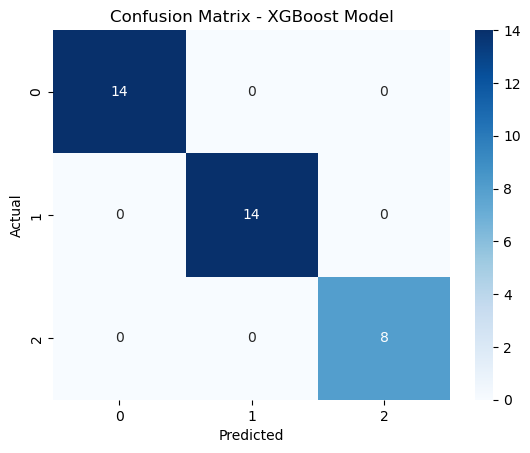

In [10]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost Model")
plt.show()


In [11]:
# Feature importance
gd_imp = pd.Series(gd.feature_importances_, index=x.columns).sort_values(ascending=False)
gd_imp

color_intensity                 3.193975e-01
proline                         3.024222e-01
od280/od315_of_diluted_wines    2.436007e-01
flavanoids                      7.945588e-02
alcohol                         2.600306e-02
ash                             1.382256e-02
malic_acid                      1.004468e-02
nonflavanoid_phenols            3.255914e-03
magnesium                       1.589886e-03
hue                             2.194897e-04
proanthocyanins                 1.850583e-04
alcalinity_of_ash               2.900077e-06
total_phenols                   1.283400e-07
dtype: float64

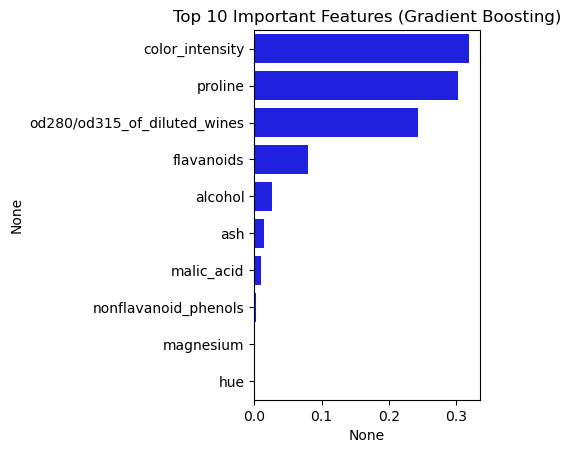

In [12]:

plt.subplot(1,2,2)
sns.barplot(x=gd_imp[:10], y=gd_imp.index[:10], color='blue')
plt.title("Top 10 Important Features (Gradient Boosting)")
plt.show()

In [13]:
input_data = ([[13.71,	5.65,	2.45,	20.5,	95.0,	1.68,	0.61,	0.52,	1.06,	7.70,	0.64,	1.74,	740.0]])
prediction = gd.predict(input_data)
prediction
if(prediction[0]==0):
    print("Wine is made from Cultivar A(grapes variety)")
elif prediction[0] == 1:
    print("Wine is made from Cultiver B(grapes variety)")
else:
    print("Wine is made from Cultiver C(grapes variety)")


Wine is made from Cultiver C(grapes variety)


c:\Users\HP\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(
